# High-Low Game Logic

Diagram (just for self-reference): 
https://miro.com/app/board/uXjVG7Qc_bU=/ 

In [63]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [64]:
class StateAgent(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int
    target_number: int

In [65]:
def setup_states(state: StateAgent) -> StateAgent:
    """
    Initial configuration on states, used, shared, and updated throughout the game
    """

    state["player_name"] = f"Welcome to the high-low game, {state["player_name"]}!"
    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = "Game started! Try to guess the number."
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    state["target_number"] = random.randint(state["lower_bound"], state["upper_bound"])

    return state

In [66]:
def guess_logic(state: StateAgent) -> StateAgent:
    """
    Node that contains the core guessing logic for the game
    """

    possible_guesses = [i for i in range(state["lower_bound"], state["upper_bound"] + 1) if i not in state["guesses"]]

    if possible_guesses:
        guess = random.choice(possible_guesses)
    else: 
        ### Fall back: defensive programming
        guess = random.randint(state["lower_bound"], state["upper_bound"])

    state["guesses"].append(guess)
    state["attempts"] += 1

    print(f"You guessed {state["guesses"][-1]} in your attepmt {state["attempts"]}/7 attempts -- Current Range: {state["lower_bound"]}-{state["upper_bound"]}")

    return state

In [67]:
def hint_logic(state: StateAgent) -> StateAgent:
    """
    Hint whether higher, lower, or correct 
    and modify possible guess number range (the lower_bound - upper_bound) 
    based on the result each time
    """

    latest_guess = state["guesses"][-1]
    target = state["target_number"]

    if latest_guess < target:
        state["hint"] = "It's too low. You should try higher..."
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1) # Safe layer with max: defensive programming
        print(f"HINT: {state["hint"]}")
    elif latest_guess > target:
        state["hint"] = "It's too high. You should try lower..."
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
        print(f"HINT: {state["hint"]}")
    else:
        state["hint"] = "You've got the correct number!"
        print(state["hint"])

    return state

In [68]:
def should_continue(state: StateAgent) -> StateAgent:
    """
    Loop node that determines whether it continues or loops back to the guess logic
    """

    latest_guess = state["guesses"][-1]
    target = state["target_number"]

    if latest_guess == target:
        print(f"Correct! The number found!!")
        return "stop"
    elif state["attempts"] >= 7: 
        print(f"Game Over: You exceeded the attempt limit...")
        return "stop"
    else: 
        print(f"Continue: {state["attempts"]}/7 attempts used")
        return "continue"

In [69]:
graph = StateGraph(StateAgent)

graph.add_node("setup_node", setup_states)
graph.add_node("guess_node", guess_logic)
graph.add_node("hint_node", hint_logic)

graph.add_edge(START, "setup_node")
graph.add_edge("setup_node", "guess_node")
graph.add_edge("guess_node", "hint_node")

graph.add_conditional_edges(
    source="hint_node",
    path=should_continue,
    path_map={
        "continue": "guess_node",
        "stop": END
    }
)

app = graph.compile()

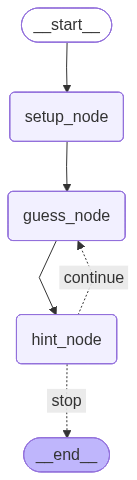

In [71]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [70]:
result = app.invoke({
    "player_name": "MyungHwan"
})

result

You guessed 3 in your attepmt 1/7 attempts -- Current Range: 1-20
HINT: It's too low. You should try higher...
Continue: 1/7 attempts used
You guessed 13 in your attepmt 2/7 attempts -- Current Range: 4-20
HINT: It's too high. You should try lower...
Continue: 2/7 attempts used
You guessed 9 in your attepmt 3/7 attempts -- Current Range: 4-12
HINT: It's too high. You should try lower...
Continue: 3/7 attempts used
You guessed 4 in your attepmt 4/7 attempts -- Current Range: 4-8
You've got the correct number!
Correct! The number found!!


{'player_name': 'Welcome to the high-low game, MyungHwan!',
 'guesses': [3, 13, 9, 4],
 'attempts': 4,
 'hint': "You've got the correct number!",
 'lower_bound': 4,
 'upper_bound': 8,
 'target_number': 4}